In [6]:
# !pip install pymysql

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql

In [8]:
# connection = pymysql.connect(
#     host="localhost",
#     user="root",
#     database="nov25",
#     port=3306
# )

# try:
#     with connection.cursor() as cursor:
#         # To get column name
#         cursor.execute("show columns from ecommerce_sales_data;")
#         columns = cursor.fetchall()
#         cols = []

#         for i in columns:
#             cols.append(i[0])

#         # to insert 
#         cursor.execute("SELECT * from ecommerce_sales_data;")
#         table = cursor.fetchall()
#         df = pd.DataFrame(table, columns=cols)
#         df.to_csv('ecommerce_sales_data.csv')
    
# finally:
#     connection.close()

In [9]:
df = pd.read_csv("ecommerce_sales_data.csv")

df.head()

,Unnamed: 0,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,0,2024-12-31,Printer,Office,North,4,3640,348.93
1,1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [10]:
df.shape

(3500, 8)

In [11]:
df.columns

Index(['Unnamed: 0', 'Order Date', 'Product Name', 'Category', 'Region',
       'Quantity', 'Sales', 'Profit'],
      dtype='object')

In [12]:
df.dtypes

Unnamed: 0        int64
Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    3500 non-null   int64  
 1   Order Date    3500 non-null   object 
 2   Product Name  3500 non-null   object 
 3   Category      3500 non-null   object 
 4   Region        3500 non-null   object 
 5   Quantity      3500 non-null   int64  
 6   Sales         3500 non-null   int64  
 7   Profit        3500 non-null   float64
dtypes: float64(1), int64(3), object(4)
memory usage: 218.9+ KB


In [14]:
df.describe()

,Unnamed: 0,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000,3500.000000
mean,1749.500000,4.931714,3047.966000,527.047203
std,1010.507298,2.575895,2440.213237,504.139732
min,0.000000,1.000000,51.000000,6.970000
25%,874.750000,3.000000,1049.500000,158.695000
50%,1749.500000,5.000000,2350.500000,361.070000
75%,2624.250000,7.000000,4537.000000,729.125000
max,3499.000000,9.000000,10782.000000,2946.930000


In [15]:
df.isnull().sum()

Unnamed: 0      0
Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [16]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [17]:
df = df.dropna()

In [18]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [22]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

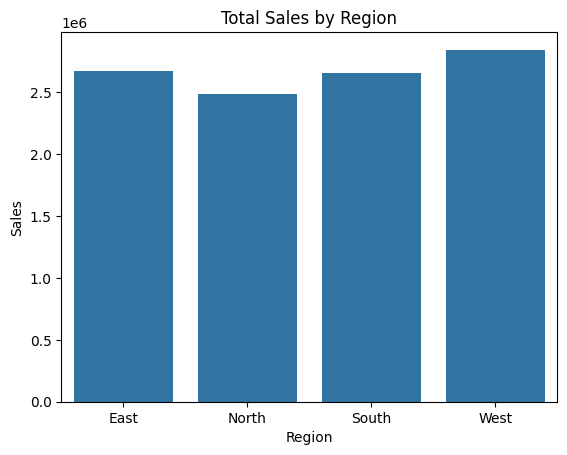

In [23]:
region_sales=df.groupby("Region")["Sales"].sum()

sns.barplot(x=region_sales.index,y=region_sales.values)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

-Total sales in west region is the highest 

-Total sales in north region is the lowest 

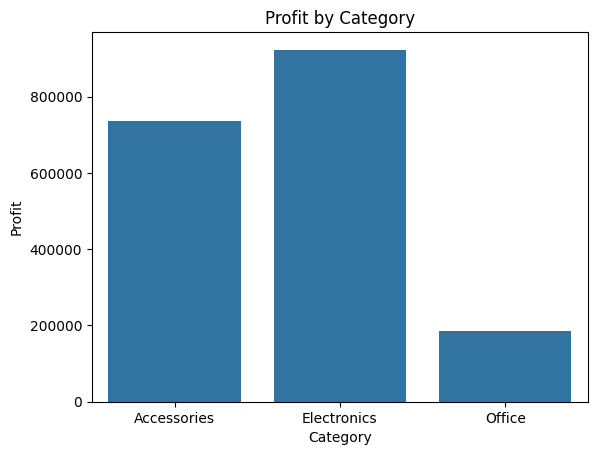

In [24]:
category_profit=df.groupby("Category")["Profit"].sum()

sns.barplot(x=category_profit.index,y=category_profit.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

Electronics have high profit by category

Office have low profit by category

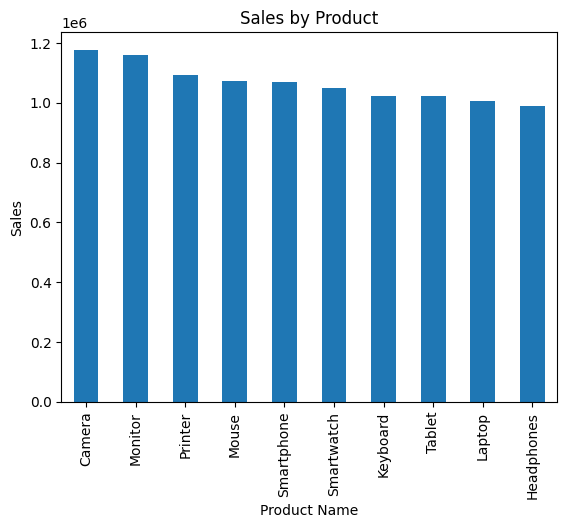

In [25]:
product_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

product_sales.plot(kind="bar")
plt.title("Sales by Product")
plt.ylabel("Sales")
plt.show()

Camera is the most saled product

Headphones is the less saled product

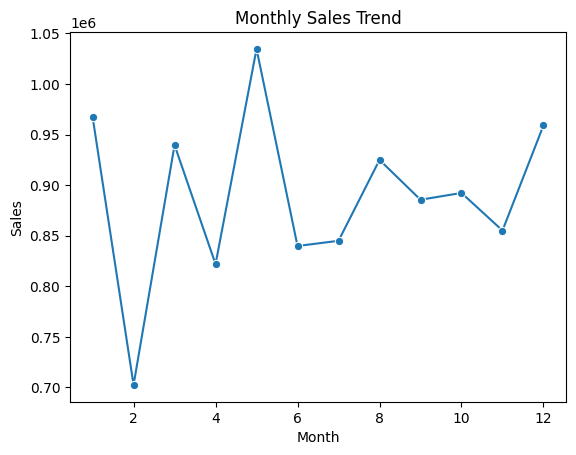

In [26]:
monthly_sales=df.groupby("Month")["Sales"].sum()

sns.lineplot(x=monthly_sales.index,y=monthly_sales.values,marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

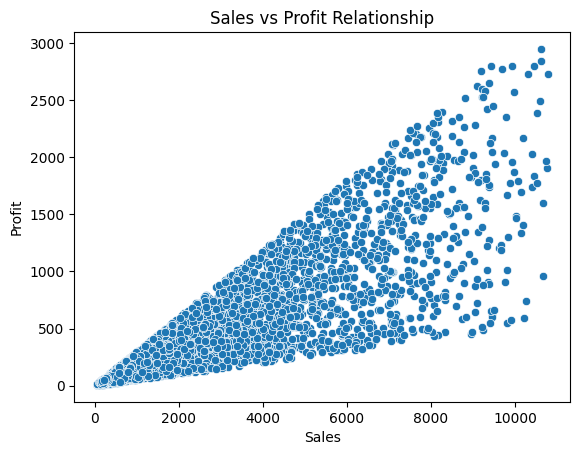

In [27]:
sns.scatterplot(x="Sales",y="Profit",data=df)
plt.title("Sales vs Profit Relationship")
plt.show()

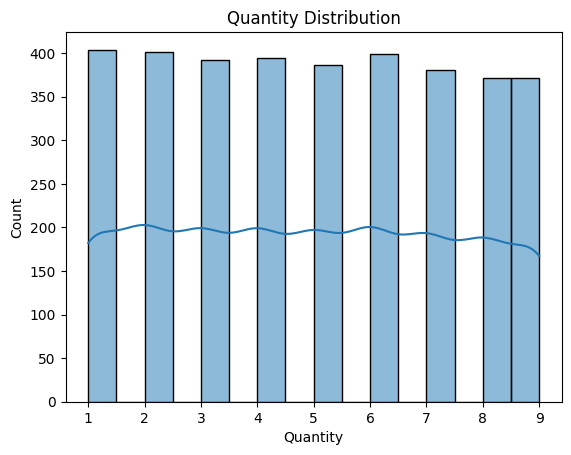

In [28]:
sns.histplot(df["Quantity"],kde=True)
plt.title("Quantity Distribution")
plt.show()

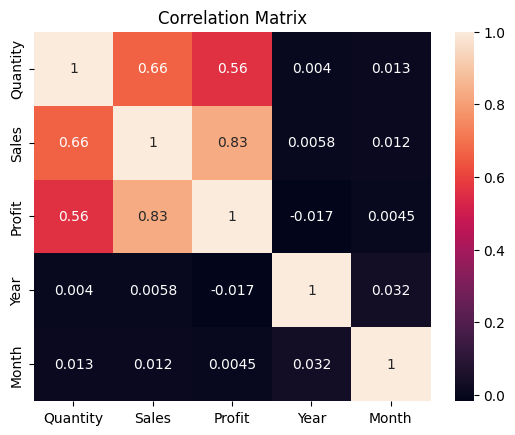

In [29]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix")
plt.show()

This shows the relationship between Sales, Profit, and Quantity.

If sales increases and profit increases → strong positive correlation.

Region Performance:
Some regions generate higher sales than others, indicating strong market demand in those locations.

Category Profitability:
Certain product categories contribute more profit, meaning the company should focus marketing efforts on those categories.

High-Selling Products:
A few products dominate sales, showing customer preference for specific items.

Sales-Profit Relationship:
There is a positive correlation between sales and profit, meaning higher sales generally lead to higher profitability.

Monthly Sales Trend:
Sales vary across months, indicating seasonal demand patterns.

Quantity Pattern:
Most orders contain a small quantity of items, suggesting customers tend to purchase fewer items per order.
